# Enumerating generalized loops

A generalized loop is an edge-induced subgraph with no vertex of degree one. In the zero-field Ising high-temperature expansion, exactly the even-degree generalized loops survive. This notebook enumerates both notions on a small graph.

In [1]:
CHAPTER_DIR = "ch09"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Enumerating edge subsets

generalized loops 9 even subgraphs 7


Saved: figs/ch09_02_generalized_loop_examples.pdf


Saved: figs/ch09_02_generalized_loop_examples.png


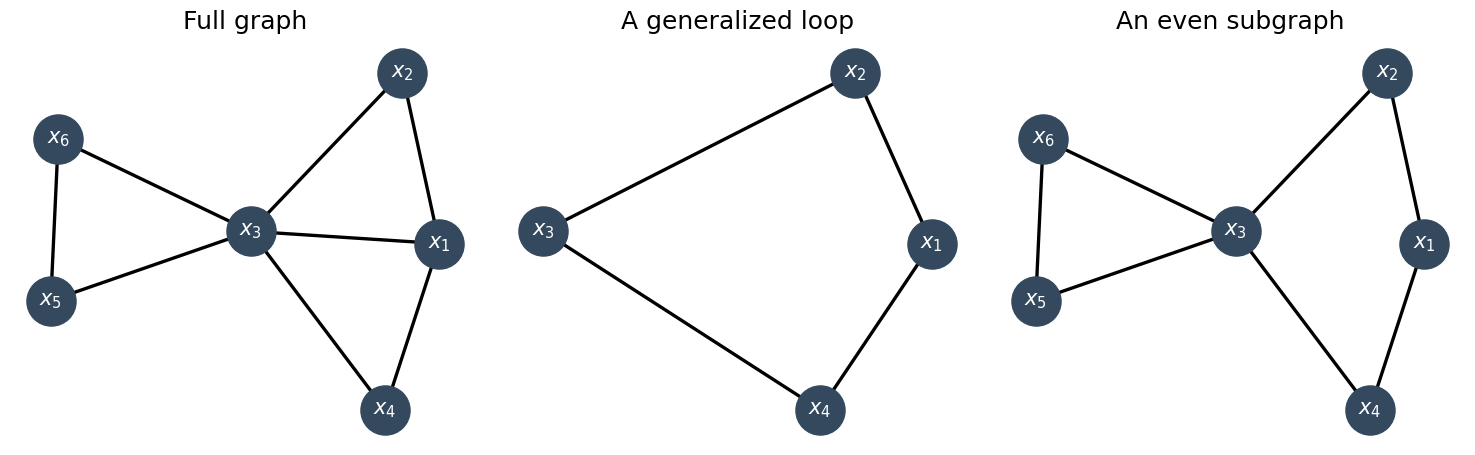

In [2]:
from itertools import combinations
G=nx.Graph(); G.add_edges_from([(0,1),(1,2),(2,3),(3,0),(0,2),(2,4),(4,5),(5,2)])
edges=list(G.edges()); generalized=[]; even=[]
for mask in range(1,1<<len(edges)):
    E=[edges[k] for k in range(len(edges)) if mask>>k&1]; H=nx.Graph(); H.add_edges_from(E); deg=[d for _,d in H.degree()]
    if min(deg)>=2:
        generalized.append(E)
        if all(d%2==0 for d in deg): even.append(E)
print('generalized loops',len(generalized),'even subgraphs',len(even))
pos=nx.spring_layout(G,seed=3)
fig,axes=plt.subplots(1,3,figsize=(15,4.8))
examples=[edges,generalized[min(2,len(generalized)-1)],even[-1]]; titles=['Full graph','A generalized loop','An even subgraph']
for ax,E,title in zip(axes,examples,titles):
    H=nx.Graph(); H.add_edges_from(E); nodes_to_draw=list(G.nodes()) if title=='Full graph' else list(H.nodes()); nx.draw_networkx_nodes(H if title!='Full graph' else G,pos,nodelist=nodes_to_draw,node_size=1250,node_color=NODE_COLOR,ax=ax); nx.draw_networkx_labels(H if title!='Full graph' else G,pos,labels={i:rf'$x_{i+1}$' for i in nodes_to_draw},font_color='white',font_size=15,ax=ax); nx.draw_networkx_edges(H,pos,edgelist=E,width=2.4,ax=ax); ax.set_title(title); ax.axis('off')
fig.tight_layout(); save_figure(fig,'ch09_02_generalized_loop_examples'); plt.show()

## High-temperature weights

For zero fields, each even subgraph contributes the product of $\tanh J_e$ over its selected edges.

,edges,weight,subgraph
3,3,0.238500,"[(2, 4), (2, 5), (4, 5)]"
1,3,0.063769,"[(0, 3), (0, 2), (2, 3)]"
0,3,0.043216,"[(0, 1), (0, 2), (1, 2)]"
2,4,0.018261,"[(0, 1), (0, 3), (1, 2), (2, 3)]"
5,6,0.015209,"[(0, 3), (0, 2), (2, 3), (2, 4), (2, 5), (4, 5)]"
4,6,0.010307,"[(0, 1), (0, 2), (1, 2), (2, 4), (2, 5), (4, 5)]"
6,7,0.004355,"[(0, 1), (0, 3), (1, 2), (2, 3), (2, 4), (2, 5..."


Saved: figs/ch09_02_loop_weight_spectrum.pdf
Saved: figs/ch09_02_loop_weight_spectrum.png


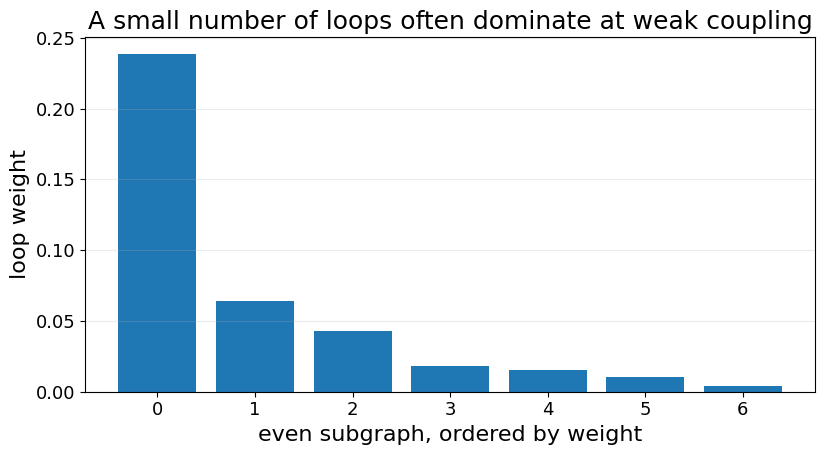

In [3]:
coupling={e:.25+.08*k for k,e in enumerate(edges)}
rows=[]
for E in even: rows.append((len(E),np.prod([np.tanh(coupling[e]) for e in E]),str(E)))
df=pd.DataFrame(rows,columns=['edges','weight','subgraph']).sort_values('weight',ascending=False); display(df.head(10))
fig,ax=plt.subplots(figsize=(8.5,4.8)); ax.bar(np.arange(len(df)),df['weight']); ax.set_xlabel('even subgraph, ordered by weight'); ax.set_ylabel('loop weight'); ax.set_title('A small number of loops often dominate at weak coupling'); ax.grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch09_02_loop_weight_spectrum'); plt.show()

## Exercises

1. Compare factor loops and generalized loops for the same normal factor graph.
2. Prove that leaf-containing terms vanish under BP consistency.
3. Design an enumeration algorithm that grows only leaf-free subgraphs instead of testing all edge subsets.